# **Bikes regression**

---

prediction-project

---

## Project Overview
  The goal of this project is to predict the amount of bikes which will be used during the particular day using different features (date, season,month,weather, weekday, humidity, etc).

  This is a supervised machine learning regression task based on the Bike Sharing Dataset.

## Objectives


*   Perform exploratory data analysis (EDA)

*   Handle missing values and outliers

*   Engineer meaningful features
*   Create and compare multiple regresiion models


*    Evaluate model performance using RMSE


*   Interpret vital features affecting daily amount of bikes rent



## Business understanding

Accurate prediction of  daily bikes rent amount can help:


*   Real businesses estimate property value
*   Investors analyze market opportunities
*   Count a proper business plan

The target variable is:
- `cnt`










In [50]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
import optuna
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import  OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models

from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

import shap
# Metrics
from sklearn.metrics import r2_score
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 0

## Loading and splitting the dataset
In this section, the dataset "day.csv" is loaded and  its basic structure is inspected. Also, train-test-validation split for training and checking our future models.

In [5]:
df=pd.read_csv('day.csv')
X=df.drop('cnt', axis=1)
y=df['cnt']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=RANDOM_STATE)
df_train=pd.concat([X_train, y_train],axis=1)
df_train.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
97,98,2011-04-08,2,0,4,0,5,1,2,0.335833,0.324479,0.836250,0.226992,172,1299,1471
503,504,2012-05-18,2,1,5,0,5,1,1,0.564167,0.551121,0.523333,0.136817,1521,6118,7639
642,643,2012-10-04,4,1,10,0,4,1,2,0.657500,0.607975,0.722917,0.117546,891,6437,7328
498,499,2012-05-13,2,1,5,0,0,0,1,0.612500,0.585238,0.576250,0.225117,2172,3946,6118
303,304,2011-10-31,4,0,10,0,1,1,1,0.340000,0.356063,0.703333,0.106350,362,3307,3669


## EDA
In this section before creating predicting models the data should be examined

In [6]:
df_train.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000
mean,365.010274,2.510274,0.496575,6.544521,0.027397,3.001712,0.691781,1.386986,0.491457,0.470773,0.623689,0.189493,840.277397,3655.010274,4495.287671
std,212.373340,1.109709,0.500417,3.460843,0.163378,1.989250,0.462153,0.537673,0.184297,0.164127,0.140206,0.076474,675.854693,1535.021817,1904.263050
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.275833,0.042304,2.000000,20.000000,22.000000
25%,177.750000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.332083,0.331115,0.514896,0.133543,309.750000,2506.750000,3193.000000
50%,363.500000,2.500000,0.000000,6.000000,0.000000,3.000000,1.000000,1.000000,0.485417,0.474744,0.621042,0.179723,717.000000,3667.000000,4547.000000
75%,547.250000,3.250000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655208,0.608289,0.723959,0.233481,1077.000000,4725.500000,5879.250000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.849167,0.826371,0.972500,0.422275,3283.000000,6946.000000,8555.000000


In [7]:
df_train.info()

<class 'pandas.DataFrame'>
Index: 584 entries, 97 to 684
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     584 non-null    int64  
 1   dteday      584 non-null    str    
 2   season      584 non-null    int64  
 3   yr          584 non-null    int64  
 4   mnth        584 non-null    int64  
 5   holiday     584 non-null    int64  
 6   weekday     584 non-null    int64  
 7   workingday  584 non-null    int64  
 8   weathersit  584 non-null    int64  
 9   temp        584 non-null    float64
 10  atemp       584 non-null    float64
 11  hum         584 non-null    float64
 12  windspeed   584 non-null    float64
 13  casual      584 non-null    int64  
 14  registered  584 non-null    int64  
 15  cnt         584 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 77.6 KB


In [8]:
df_train.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

From the info above, I can conclude that initial dataset is clean and all info almost numeric. Talking about `instant` is a column which contains record index and `dteday` is a column which contains date. Both this columns will be dropped because 
1) record index can't give vital information our model 
2) date would be useful if we didn't have such columns as `season`,`yr`,`month`, `holiday`,`weekday`, `workingday`.

In [9]:
df_train_prepr=df_train.drop(['instant','dteday'], axis=1)
df_train_prepr.corr()['cnt'].sort_values(ascending=False)

cnt           1.000000
registered    0.945188
casual        0.670823
atemp         0.637151
temp          0.636663
yr            0.567386
season        0.389705
mnth          0.279523
weekday       0.055327
workingday    0.041949
holiday      -0.049491
hum          -0.101159
windspeed    -0.245648
weathersit   -0.263971
Name: cnt, dtype: float64

<Axes: >

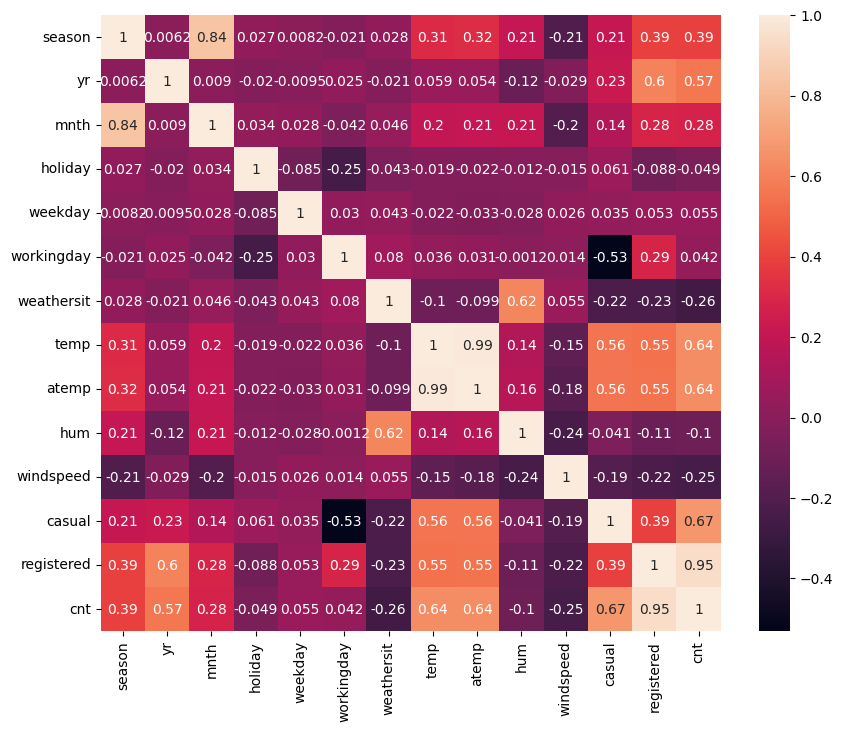

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df_train_prepr.corr(), annot=True, fmt=".2g")

Features like `registered` (count of registered users), `casual` (count of casual users),`atemp` (Normalized feeling temperature in Celsius. The values are divided to 50 (max)),`temp`(Normalized temperature in Celsius. The values are divided to 41 (max)) have the highest correlation with `cnt` and their values are positive which means the higher one value, the higher daily count of bikes. 
!!! But `casual`+`registered`=`cnt`, so that later I will have to drop it to avoid data leakage. And also `atemp` and `temp` have 0.99 correlation which means that they are almost the same, so that we should delete one of them.

Text(0.5, 1.0, 'Correlation between count and atemp with the division by year')

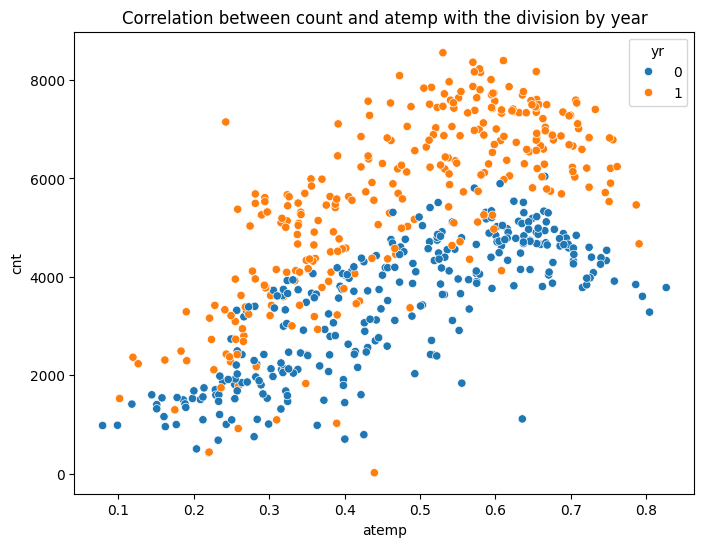

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_train_prepr,x='atemp',y='cnt',hue='yr')
plt.title('Correlation between count and atemp with the division by year')
# 0 - 2011 
# 1 - 2012

The above it is shown that the higher the year, the more bikes are used and with apparent temperature the count of bikes increases.

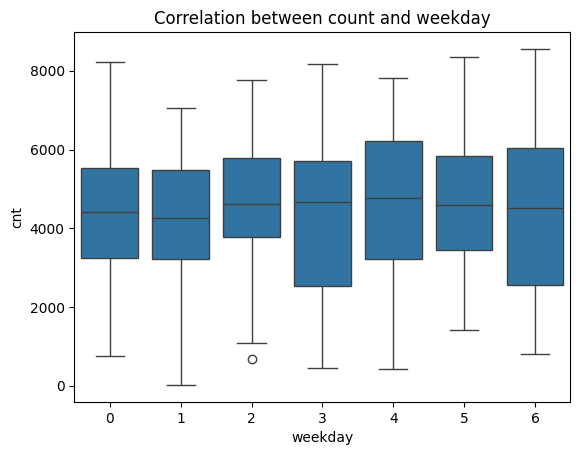

In [12]:
sns.boxplot(x='weekday',y='cnt',data=df_train_prepr)
plt.title("Correlation between count and weekday")
plt.show()

It is peculiar to see that almost every day of the week median amount of bikes is almost the same. The most amount is used on Thursday and the least is on Saturday and Wednesday.

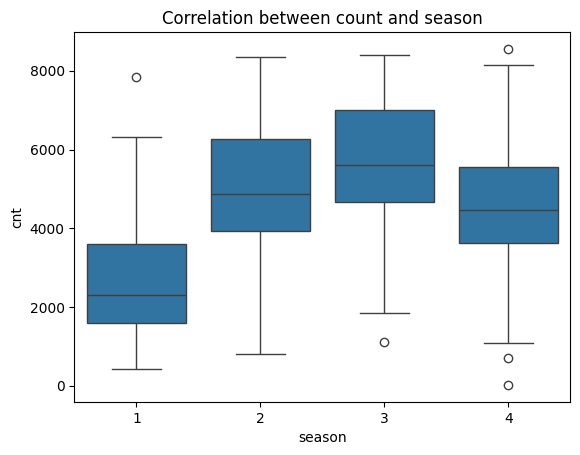

In [54]:
sns.boxplot(x='season',y='cnt',data=df_train_prepr)
plt.title("Correlation between count and season")
plt.show()

`season` : season (1:springer, 2:summer, 3:fall, 4:winter)
 
More bikes are rented in fall and spring. The least amount of bikes rented is in spring

## Evaluation Metric
The model was evaluated using R2. It is a statistical measure that indicates how well a regression model fits the observed data. It represents the proportion of variance in the dependent variable that is predictable from the independent variable. The score typically ranges from 0 to 1, with a higher value indicating a better fit. A score of 1 means the model perfectly explains all the variance in the data, while a score of 0 means the model explains none of the variance. It is important to note that the score can be negative, which indicates that the model is performing worse than simply using the mean of the target values as a prediction.

## Hyperparameter Tuning
While creating the model, I will compare which metrics is the highest with the hyperparams discovered using GridSearchCV and Optuna. In this section the functions for such search will be created.

In [40]:
def tune_grid_search(X_t,y_t,pipeline, params):
    grid=GridSearchCV( estimator=pipeline, param_grid=params,cv=5,scoring='r2',n_jobs=-1)
    grid.fit(X_t,y_t)
    report = {
        'best_params':grid.best_params_,   
        'best_score':grid.best_score_   }
    return grid.best_estimator_, report
def tune_optuna(obj_func):
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study=optuna.create_study(direction='maximize')
    study.optimize(obj_func, n_trials=50, n_jobs=-1)
    report = {
        'best_params':study.best_params,   
        'best_score':study.best_value  }
    return report

 ## Preprocessing
 

In [33]:
num_cols=[]
cat_cols=[]
for col in X_train.columns:
    if X_train[col].dtype == "int64" or X_train[col].dtype == "float64":
        num_cols.append(col)
    else:
        cat_cols.append(col)

if "instant" in num_cols:
    num_cols.remove("instant")
if "casual" in num_cols:
    num_cols.remove("casual")
if "registered" in num_cols:
    num_cols.remove("registered")
if "atemp" in num_cols:
    num_cols.remove("atemp")
if "dteday" in cat_cols:
    cat_cols.remove("dteday")

numerical_transformer=SimpleImputer(strategy='median')
categorial_transformer=Pipeline(steps=
                                [('imputer', SimpleImputer(strategy='most_frequent')),
                                ('onehot', OneHotEncoder(handle_unknown='ignore')) ])
preprocessor=ColumnTransformer(transformers=[('num',numerical_transformer,num_cols),
                                             ('cat',categorial_transformer,cat_cols)], remainder='drop')



## Random Forest Regressor model

This model performs well on structured tabular data and can capture nonlinear relationships between features. Also, it has many interaction and categorial effects.

In [35]:
rf_model=Pipeline(steps=[('preprocessor',preprocessor),('model',RandomForestRegressor())])
rf_params_grid={
    'model__n_estimators': [100,150,200,250],
    'model__max_depth': [None,10,20,30],
    'model__max_features': ['sqrt','log2',0.33],
    'model__min_samples_leaf': [1,2,3,4],
}
best_estimator_rf,rf_report=tune_grid_search(X_train, y_train, pipeline=rf_model,params=rf_params_grid)
print('GridSearchCV')
print(rf_report['best_params'])
print(rf_report['best_score'])

GridSearchCV
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
0.8718476553339745


In [41]:
def rf_objective(trial):
    params={
        'model__n_estimators': trial.suggest_int('model__n_estimators',50,250,step=50),
        'model__max_depth': trial.suggest_categorical( 'model__max_depth',[None,10,20,30]),
        'model__max_features':  trial.suggest_float('model__max_features', 0.1, 0.8),
        'model__min_samples_leaf':  trial.suggest_int("model__min_samples_leaf", 1, 5),
    }
    rf_pipeline_opt=rf_model.set_params(**params)
    scores=cross_val_score(rf_pipeline_opt,X_train,y_train,cv=5,scoring='r2', n_jobs=-1)
    return scores.mean()
rf_report_optuna=tune_optuna(rf_objective)
print('Optuna')
print(rf_report_optuna['best_params'])
print(rf_report_optuna['best_score'])

Optuna
{'model__n_estimators': 200, 'model__max_depth': 20, 'model__max_features': 0.6066098219816841, 'model__min_samples_leaf': 2}
0.8724973009985055


Optuna performed a little better which is logical because it searches for hyperparams with different structures so that on final model I will use optuna.

In [43]:
best_params = rf_report_optuna["best_params"]
rf_final_model=rf_model.set_params(**best_params)
rf_final_model.fit(X_train,y_train)
y_rf_pred=rf_final_model.predict(X_test)
rf_r2 = r2_score(y_test, y_rf_pred)

print(f"R2 from RandomForest: {rf_r2:.5f}")

R2 from RandomForest: 0.89536


## LightGBM
It is an open-source high-performance gradient boosting framework which is based on decision tree algorithms and is used for classification, regression, ranking, and other machine learning tasks.

In [46]:
lgb_model=Pipeline(steps=[('preprocessor',preprocessor),('model',LGBMRegressor(random_state=RANDOM_STATE,verbosity=-1))])
def lgb_objective(trial):
    params={
        'model__n_estimators': trial.suggest_int('model__n_estimators',50,250,step=50),
        'model__max_depth': trial.suggest_categorical( 'model__max_depth',[None,10,20,30]),
        'model__max_features':  trial.suggest_float('model__max_features', 0.1, 0.8),
        "model__learning_rate": trial.suggest_float("model__learning_rate", 0.01, 0.2, log=True),
        'model__min_child_samples':  trial.suggest_int("model__min_child_samples", 5, 50),
    }
    lgb_pipeline_opt=lgb_model.set_params(**params)
    scores=cross_val_score(lgb_pipeline_opt,X_train,y_train,cv=5,scoring='r2', n_jobs=-1)
    return scores.mean()
lgb_report_optuna=tune_optuna(lgb_objective)
print('Optuna')
print(lgb_report_optuna['best_params'])
print(lgb_report_optuna['best_score'])

Optuna
{'model__n_estimators': 250, 'model__max_depth': 10, 'model__max_features': 0.43684812422467995, 'model__learning_rate': 0.13140442917747375, 'model__min_child_samples': 45}
0.8794472682384269


In [48]:
best_params = lgb_report_optuna["best_params"]
lgb_final_model=lgb_model.set_params(**best_params)
lgb_final_model.fit(X_train,y_train)
y_lgb_pred=lgb_final_model.predict(X_test)
lgb_r2 = r2_score(y_test, y_lgb_pred)

print(f"R2 from LGB Model: {lgb_r2:.5f}")

R2 from LGB Model: 0.87580


## Comparison of RandomForest and LGB regressors

n this project, we developed, optimized, and evaluated two distinct machine learning pipelines—Random Forest Regressor and LightGBM Regressor—to predict bicycle rental demand using the Bike Sharing Dataset. Data leakage issues (such as casual and registered counts) were successfully identified and removed to ensure a clean, realistic evaluation.Both models were hyperparameter-tuned using Optuna over 50 trials on a 5-fold cross-validation setup.


In [49]:
results = pd.DataFrame({
    "Model": [
        "LGB Regression",
        "Random Forest Regression"
        ],
    "R2": [
        lgb_r2,
        rf_r2]
    
})

results

,Model,R2
0,LGB Regression,0.875799
1,Random Forest Regression,0.895362


While LightGBM is widely regarded as a more advanced gradient boosting framework, **Random Forest achieved a higher accuracy on the test set by approximately 2%**. This outcome is driven by several key data-architectural factors:

*   **Dataset Scale Constraints:** 
    Gradient boosting algorithms are highly complex and require massive amounts of data—typically tens of thousands of rows—to effectively learn without overfitting. Because the daily version of this dataset is relatively small, LightGBM tended to overfit to localized noise. Random Forest relies on bagging (averaging independent deep trees), which naturally buffers against overfitting on smaller samples.
*   **Robustness to Noise and Outliers:** 
    LightGBM builds trees sequentially, with each new tree forcing the model to correct the errors of the previous ones. On smaller datasets, this behavior often causes the model to aggressively chase outliers (e.g., unexpected demand spikes on specific holidays). Random Forest does not correct errors sequentially; its averaging mechanism dilutes the impact of individual anomalies, yielding a more stable prediction on the test set.
*   **Handling of One-Hot Encoded Features:** 
    The preprocessing pipeline utilized `OneHotEncoder` to transform categorical attributes, expanding the feature space into a sparse matrix of binary columns. Random Forest handles sparse, one-hot encoded variables seamlessly. LightGBM, however, is architecturally optimized to perform splits on continuous scales or raw integer categories via its native categorical handling. The introduction of one-hot encoded matrices degraded LightGBM’s capacity to find optimal split points.
*   **Hyperparameter Search Space Complexity:** 
    Random Forest is highly robust "out-of-the-box" and its hyperparameter landscape is simpler to navigate. LightGBM requires careful, precise co-tuning of regularization parameters (`reg_alpha`, `reg_lambda`), tree structure limits (`num_leaves`), and learning rates (`learning_rate`) to prevent overfitting on tight data distributions, which requires far more optimization cycles.


## SHAP

It is a method for interpreting machine learning model predictions based on game theory and the concept of Shapley values. It allows you to understand how each feature (input characteristic) contributes to the final prediction of the model, providing both local and global interpretability. In our project Random Forest performed better, so that the research will be held on that model.

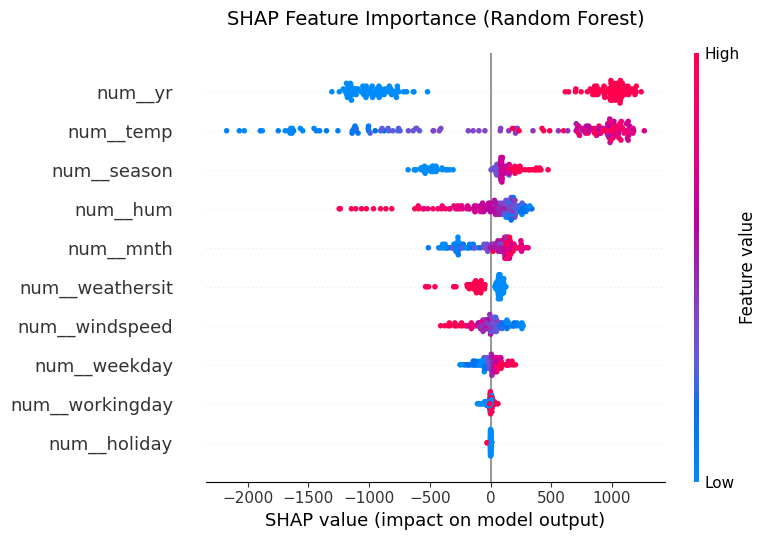

In [53]:
tr_preprocessor=rf_final_model.named_steps['preprocessor']
X_test_pr=tr_preprocessor.transform(X_test)

all_features = tr_preprocessor.get_feature_names_out()

X_test_df = pd.DataFrame(X_test_pr, columns=all_features)

rf_model_step=rf_final_model.named_steps["model"]
explainer=shap.TreeExplainer(rf_model_step)
shap_values=explainer(X_test_df)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title("SHAP Feature Importance (Random Forest)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

From the plot above I can summarize that year,temperature, season affect amount of bikes rented. 
* There is a tendency that with every year more and more bikes are rented
* The higher temperature, the higher amount of bikes
* Bikes are rented mostly in fall and summer

## Conclusion
This project focused on predicting the daily number of rented bicycles using machine learning regression models. The dataset was explored through exploratory data analysis, which revealed that weather conditions, season, year, and temperature have the strongest influence on bike rental demand.

Two regression algorithms, Random Forest and LightGBM, were trained and optimized using Optuna. Although both models produced accurate predictions, Random Forest achieved slightly better performance on the test dataset, demonstrating greater robustness for this relatively small tabular dataset.

Model interpretation using SHAP showed that features such as year, temperature, season, and registered users contributed the most to the prediction, making the model more transparent and easier to understand.

Overall, the project demonstrates the complete machine learning workflow: data exploration, preprocessing, model training, hyperparameter optimization, evaluation, comparison, and interpretation. The resulting model can be used to estimate future bicycle rental demand and may help optimize bike availability and resource planning.